# Hackathon EDA -  Equipo 1:  Perspectiva térmica
Integrantes:
- Benjamín Cádiz
- Amelia Díaz
- Catalina González
- Monserrat Zúñiga


# Objetivo del análisis
El objetivo de este trabajo es realizar un análisis exploratorio de datos (EDA) profundo y estructurado sobre el catálogo de exoplanetas *Habitable Worlds Catalog* (HWC), abordándolo desde una perspectiva térmica, utilizando variables específicas relacionadas con la temperatura y características similares.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="darkgrid")
plt.rcParams.update({'figure.max_open_warning': 0})

# Contexto y variables relevantes
Nuestro análisis aborda el catálogo desde una perspectiva térmica. Nos enfocamos en evaluar las condiciones energéticas de los planetas para distinguir cuales poseen las mejores características térmicas para ser habitables. Filtramos las temperaturas extremas predominantes en el catálogo y nos centramos en los candidatos con condiciones moderadas.

Seleccionamos un subconjunto de variables que nos permiten cuantificar el potencial térmico de cada planeta. Incluímos la temperatura de equilibrio (P_TEMP_EQUIL), la temperatura superficial (P_TEMP_SURF), la distancia orbital (P_SEMI_MAJOR_AXIS) y el flujo estelar recibido (P_FLUX). A partir del flujo calculamos FLUX_DIFF_EARTH para medir la exactitud de la radiación respecto a nuestro planeta. Finalmente utilizamos las columnas de los límites de las zonas habitables (P_HABZONE_CON y P_HABZONE_OPT) y el índice de similitud con la tierra (P_ESI) para filtrar y priorizar a nuestros candidatos, además incorporamos la variable (S_TYPE_TEMP) para entender en qué tipos de sistemas son más propensos a encontrarse planetas habitables. Para asegurar la validez de los resultados, los datos han sido limpiados de valores nulos en nuestras columnas fundamentales.

El análisis se sostendrá bajo la hipótesis de que el flujo estelar es un predictor térmico más robusto que el semieje mayor
por sí solo, ya que normaliza la energía recibida independientemente de la luminosidad de la estrella.
Postulamos que los planetas con un flujo cercano a 1.0 (similar a la Tierra) dentro de la Zona Habitable
Conservadora tendrán temperaturas de equilibrio óptimas para el agua líquida, independientemente de su tipo estelar.

In [ ]:
#Carga e inspección inicial de los datos
df = pd.read_csv('hwc.csv')

# Selección de columnas
cols_termicas = [
    'P_NAME', 'P_FLUX', 'P_TEMP_EQUIL', 'P_TEMP_SURF', 'P_SEMI_MAJOR_AXIS',
    'S_LUMINOSITY', 'S_TEMPERATURE', 'P_DISTANCE_EFF',
    'P_HABZONE_OPT', 'P_HABZONE_CON', 'S_TYPE_TEMP'
    'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'P_ESI', 'P_HABITABLE'
]

cols_presentes = [col for col in cols_termicas if col in df.columns]
df_termico = df[cols_presentes].copy()

print("DESCRIPCIÓN DEL DATASET (VARIABLES TÉRMICAS)")
print(f"Planetas totales en el catálogo: {df_termico.shape[0]}")
print("\nValores nulos en variables clave:")
print(df_termico[['P_FLUX', 'P_TEMP_EQUIL', 'P_SEMI_MAJOR_AXIS', 'S_LUMINOSITY', 'P_HABZONE_CON']].isnull().sum())
print("\nTipos de variables:\n", df_termico.dtypes)

DESCRIPCIÓN DEL DATASET (VARIABLES TÉRMICAS)
Planetas totales en el catálogo: 5599

Valores nulos en variables clave:
P_FLUX               234
P_TEMP_EQUIL         234
P_SEMI_MAJOR_AXIS      4
S_LUMINOSITY         233
P_HABZONE_CON          0
dtype: int64

Tipos de variables:
 P_NAME                object
P_FLUX               float64
P_TEMP_EQUIL         float64
P_TEMP_SURF          float64
P_SEMI_MAJOR_AXIS    float64
S_LUMINOSITY         float64
S_TEMPERATURE        float64
P_DISTANCE_EFF       float64
P_HABZONE_OPT          int64
P_HABZONE_CON          int64
S_HZ_CON_MAX         float64
P_ESI                float64
P_HABITABLE            int64
dtype: object


# Limpieza de datos

In [ ]:
# Excluir planetas sin datos críticos de flujo, temperatura o distancia
df_clean = df_termico.dropna(subset=['P_TEMP_EQUIL', 'P_FLUX', 'P_SEMI_MAJOR_AXIS', 'P_ESI']).copy()

# Diferencia de flujo respecto al de la Tierra
df_clean['FLUX_DIFF_EARTH'] = abs(df_clean['P_FLUX'] - 1)

# Outliers : Planetas dentro de zona habitable, pero con temperaturas extremas.
if 'P_HABZONE_CON' in df_clean.columns:
    outliers = df_clean[
        (df_clean['P_HABZONE_CON'] == 1) &
        ((df_clean['P_TEMP_EQUIL'] > 350) | (df_clean['P_TEMP_EQUIL'] < 180))
    ]
    print(f"Se encontraron {len(outliers)} anomalías: Planetas en la Zona Habitable Conservadora pero con Temperaturas de Eq. extremas.")
    print(outliers[['P_NAME', 'P_TEMP_EQUIL', 'P_FLUX', 'P_SEMI_MAJOR_AXIS', 'S_LUMINOSITY']].head())


Se encontraron 0 anomalías: Planetas en la Zona Habitable Conservadora pero con Temperaturas de Eq. extremas.
Empty DataFrame
Columns: [P_NAME, P_TEMP_EQUIL, P_FLUX, P_SEMI_MAJOR_AXIS, S_LUMINOSITY]
Index: []


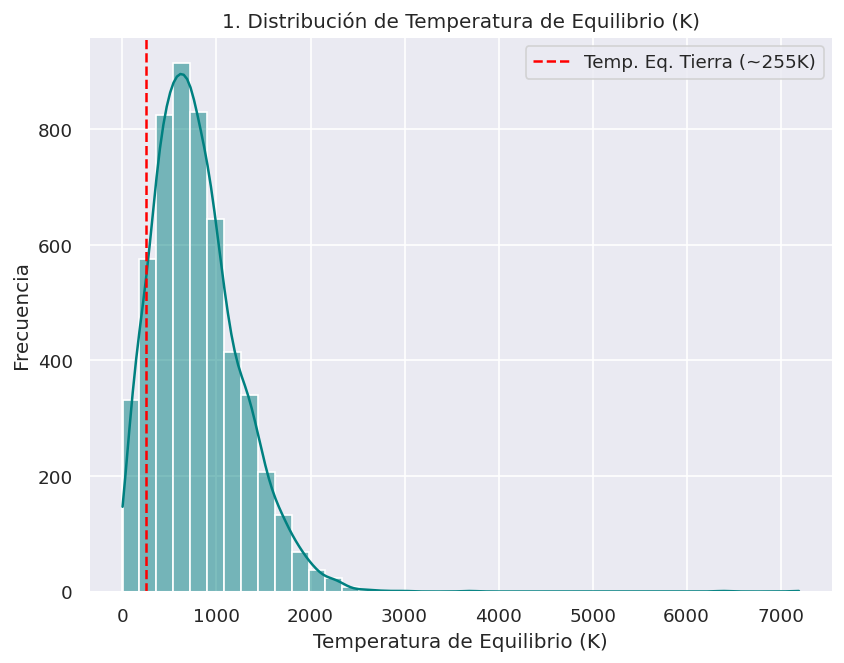

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

# Distribución de la Temperatura de Equilibrio
sns.histplot(df_clean['P_TEMP_EQUIL'], bins=40, color='teal', kde=True, axes = ax)
ax.axvline(x=255, color='red', linestyle='--', label='Temp. Eq. Tierra (~255K)')
ax.set_title('1. Distribución de Temperatura de Equilibrio (K)')
ax.set_xlabel('Temperatura de Equilibrio (K)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.show()

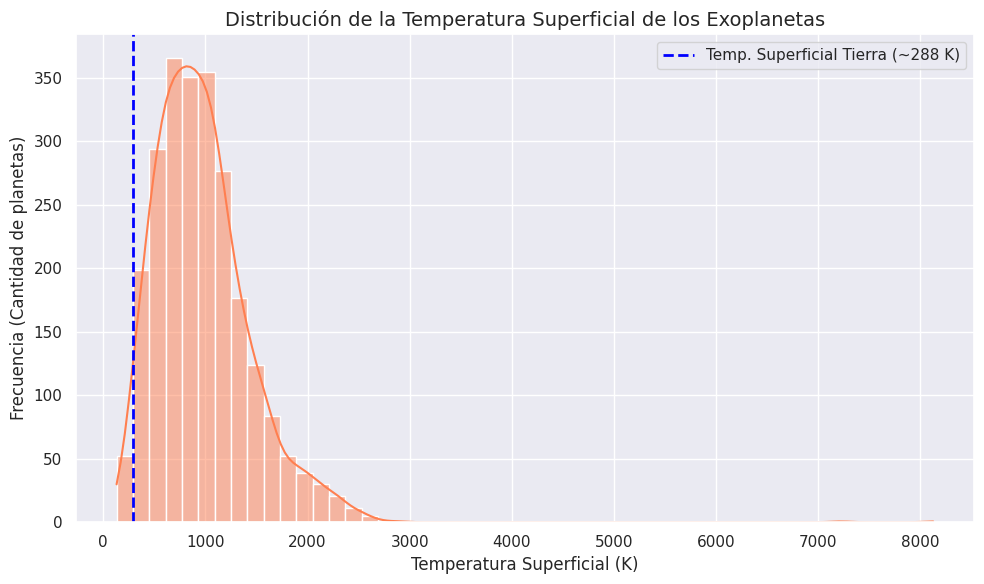

In [ ]:
# Distribución de la Temperatura Superficial
plt.figure(figsize=(10, 6))
# Usamos histplot para ver la frecuencia y kde=True para la curva de tendencia
sns.histplot(data=df, x='P_TEMP_SURF', bins=50, kde=True, color='coral')

# Agregamos la línea vertical de referencia para la Tierra
plt.axvline(x=288, color='blue', linestyle='--', linewidth=2, label='Temp. Superficial Tierra (~288 K)')

plt.title('Distribución de la Temperatura Superficial de los Exoplanetas', fontsize=14)
plt.xlabel('Temperatura Superficial (K)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de planetas)', fontsize=12)

plt.legend()

plt.tight_layout()
plt.show()

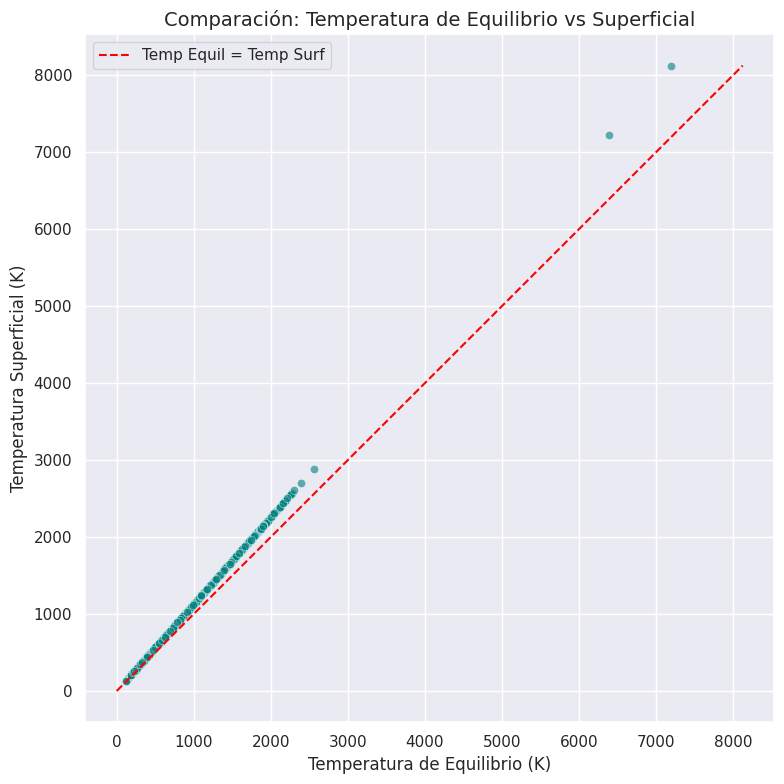

In [ ]:
# Comparación Temp. Equilibrio vs Superficial
plt.figure(figsize=(8, 8))
# Graficamos ambas temperaturas.
sns.scatterplot(data=df, x='P_TEMP_EQUIL', y='P_TEMP_SURF', alpha=0.6, color='teal')

# Agregamos una línea roja diagonal de referencia donde X = Y
# Esto representa los casos donde la Temp de Equilibrio es igual a la Superficial
max_temp = max(df['P_TEMP_EQUIL'].max(), df['P_TEMP_SURF'].max())
plt.plot([0, max_temp], [0, max_temp], color='red', linestyle='--', label='Temp Equil = Temp Surf')

plt.title('Comparación: Temperatura de Equilibrio vs Superficial', fontsize=14)
plt.xlabel('Temperatura de Equilibrio (K)', fontsize=12)
plt.ylabel('Temperatura Superficial (K)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

## EXPLICACIÓN GRÁFICO 1

Al analizar las distribuciones de temperatura de equilibrio y superficial con su comparación directa, se identifica que los dos tipos de datos tienen distribuciones inclinadas hacia valores altos, con una mayoría de planetas cálidos y una escasa representación de temperaturas cercanas a las terrestres. Esto indica que los planetas con alta irradiación predominan en el conjunto de datos, mientras que los planetas templados son menos comunes.

La comparación entre ambas temperaturas muestra una relación fuertemente correlacionada, ya que la mayoría de los puntos están alineados cerca de la línea donde la temperatura de la superficie es igual a la de equilibrio. Esto indica que la temperatura superficial está determinada por la radiación estelar incidente. Sin embargo, se observan desviaciones de esta relación, sugiriendo la influencia de otros factores, tales como efectos atmosféricos que pueden aumentar la temperatura superficial por encima de la de equilibrio.

En conjunto, estos resultados destacan que la temperatura de equilibrio es una buena aproximación inicial para caracterizar el estado térmico de un planeta,  pero por sí sola no es suficiente para describir sus condiciones reales. Además, la baja presencia de valores cercanos a los terrestres en ambas distribuciones refuerza la idea de un sesgo observacional en la detección de exoplanetas. Por eso, la búsqueda de candidatos de interés implica considerar planetas que se encuentren cerca de estas condiciones, pero también hay que analizar las diferencias entre ambas temperaturas como posible indicador de procesos físicos relevantes.


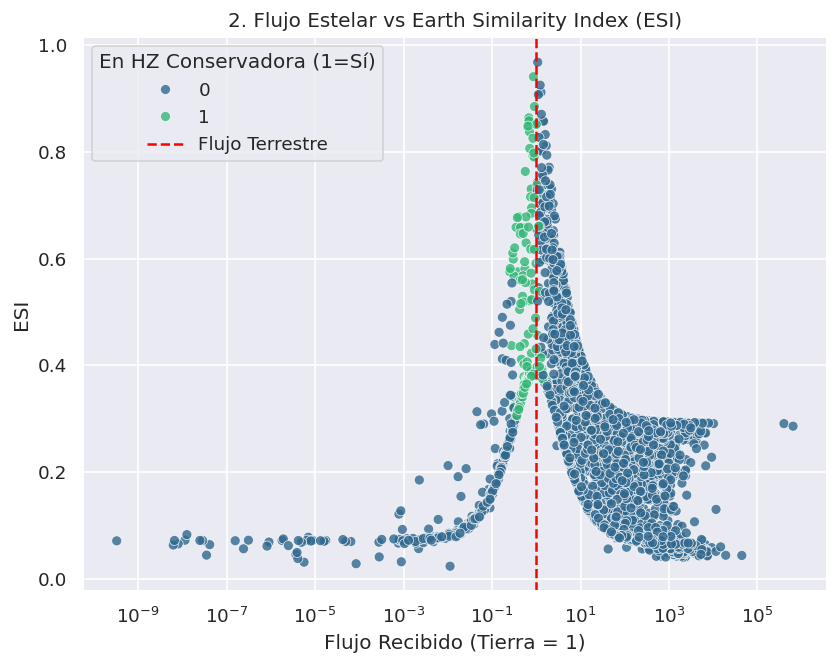

In [ ]:
fig2, ax2 = plt.subplots(figsize=(8, 6), dpi=120)

# Flujo vs Índice de Similitud (ESI)
sns.scatterplot(data=df_clean, x='P_FLUX', y='P_ESI', hue='P_HABZONE_CON', palette='viridis', alpha=0.8, ax=ax2)
ax2.set_title('2. Flujo Estelar vs Earth Similarity Index (ESI)')
ax2.set_xlabel('Flujo Recibido (Tierra = 1)')
ax2.set_ylabel('ESI')
ax2.set_xscale('log')
ax2.axvline(x=1, color='red', linestyle='--', label='Flujo Terrestre')
ax2.legend(title='En HZ Conservadora (1=Sí)')
plt.show()

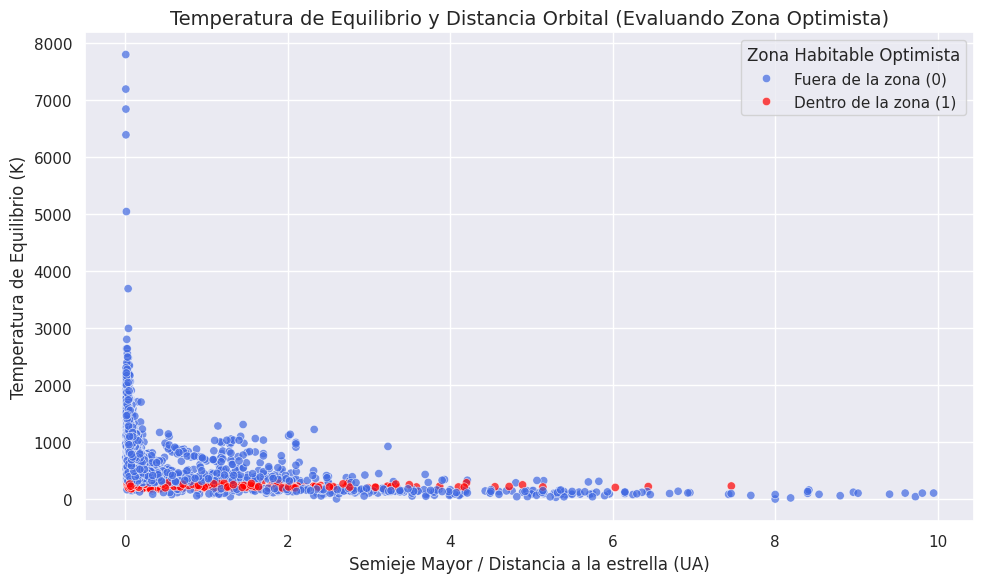

In [ ]:
plt.figure(figsize=(10, 6))

# Filtramos valores extremos (y usamos .copy())
df_filtrado = df[df['P_SEMI_MAJOR_AXIS'] < 10].copy()

# Creamos una columna temporal con los nombres exactos para la leyenda
df_filtrado['Etiqueta_Zona'] = df_filtrado['P_HABZONE_OPT'].map({
    0: 'Fuera de la zona (0)',
    1: 'Dentro de la zona (1)'
})

# Hacemos el gráfico usando la columna temporal
sns.scatterplot(data=df_filtrado,
                x='P_SEMI_MAJOR_AXIS',
                y='P_TEMP_EQUIL',
                hue='Etiqueta_Zona',
                palette={'Fuera de la zona (0)': 'royalblue', 'Dentro de la zona (1)': 'red'}, # Asignamos colores fijos
                alpha=0.7)

plt.title('Temperatura de Equilibrio y Distancia Orbital (Evaluando Zona Optimista)', fontsize=14)
plt.xlabel('Semieje Mayor / Distancia a la estrella (UA)', fontsize=12)
plt.ylabel('Temperatura de Equilibrio (K)', fontsize=12)

plt.legend(title='Zona Habitable Optimista')

plt.tight_layout()
plt.show()

### EXPLICACIÓN GRÁFICO 2

Al analizar estos gráficos se puede observar un patrón físico consistente en ambos casos. En el gráfico “Flujo Estelar vs Earth Similarity Index” se ve que la temperatura de equilibrio disminuye con la distancia a la estrella, lo que es un reflejo directo de la dependencia de la irradiación estelar con la distancia. Los planetas que se encuentran dentro de la zona habitable optimista se concentran en un rango intermedio de distancias y temperaturas, evitando tanto los regímenes extremadamente calientes (cerca de la estrella) como los muy fríos (a grandes distancias).

Este comportamiento se complementa con el segundo gráfico, donde el ESI alcanza sus mayores valores alrededor de un flujo estelar cercano al terrestre (≈1). Se ve que los planetas dentro de la zona habitable conservadora tienden a agruparse justo en esta región, lo que sugiere que en condiciones similares a las de la Tierra, en términos de energía recibida, son cruciales para maximizar la similitud planetaria. A medida que el flujo estelar se aleja de este valor, ya sea hacia valores muy bajos o muy altos, el ESI se reduce considerablemente, lo que indica que las condiciones para la habitabilidad son cada vez.

Entonces, ambos gráficos muestran que la habitabilidad potencial está fuertemente controlada por la cantidad de energía que recibe el planeta, la cual depende de su distancia a la estrella. En esa relación, la temperatura de equilibrio es un factor de enlace clave, mientras que el ESI combina múltiples factores para evaluar lo parecido que es un planeta a la Tierra. Sin embargo, también se observa dispersión en los datos, lo que sugiere que otros factores, como las propiedades atmosféricas o características internas del planeta, también afectan estas métricas. Por lo tanto, aunque la distancia orbital y el flujo estelar son variables fundamentales, por sí solas no son suficientes para determinar la habitabilidad, sino que deben considerarse en conjunto con otros parámetros físicos.


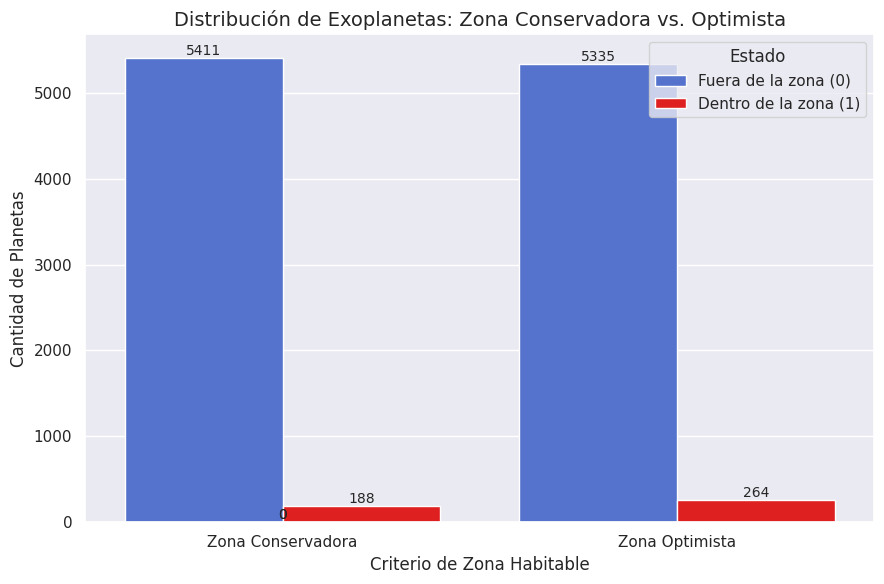

In [ ]:
plt.figure(figsize=(9, 6))

# Seleccionamos solo las dos columnas que nos interesan y usamos .melt
# para que Seaborn pueda graficarlas juntas fácilmente
df_zonas = df[['P_HABZONE_CON', 'P_HABZONE_OPT']].melt(
    var_name='Tipo_de_Zona',
    value_name='Estado'
)

# Renombramos los valores
df_zonas['Tipo_de_Zona'] = df_zonas['Tipo_de_Zona'].map({
    'P_HABZONE_CON': 'Zona Conservadora',
    'P_HABZONE_OPT': 'Zona Optimista'
})

df_zonas['Estado'] = df_zonas['Estado'].map({
    0: 'Fuera de la zona (0)',
    1: 'Dentro de la zona (1)'
})

# Creamos el gráfico de barras agrupadas
sns.countplot(data=df_zonas,
              x='Tipo_de_Zona',
              hue='Estado',
              palette={'Fuera de la zona (0)': 'royalblue', 'Dentro de la zona (1)': 'red'})

plt.title('Distribución de Exoplanetas: Zona Conservadora vs. Optimista', fontsize=14)
plt.xlabel('Criterio de Zona Habitable', fontsize=12)
plt.ylabel('Cantidad de Planetas', fontsize=12)

# Añadimos los valores exactos sobre cada barra para mayor rigor
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

## EXPLICACIÓN

Al analizar la distribución de exoplanetas de acuerdo a la zona habitable conservadora y optimista, se observa en ambos casos que la gran mayoría de los planetas se encuentran fuera de la zona habitable, mientras que solo una pequeña fracción se encuentra dentro de ella. Sin embargo, el criterio optimista tiene un número mayor de planetas habitables, lo que es consistente con una definición más amplia de las condiciones necesarias de la habitabilidad. Esto indica que, independiente del criterio utilizado, los planetas potencialmente habitables representan una proporción reducida del total analizado.

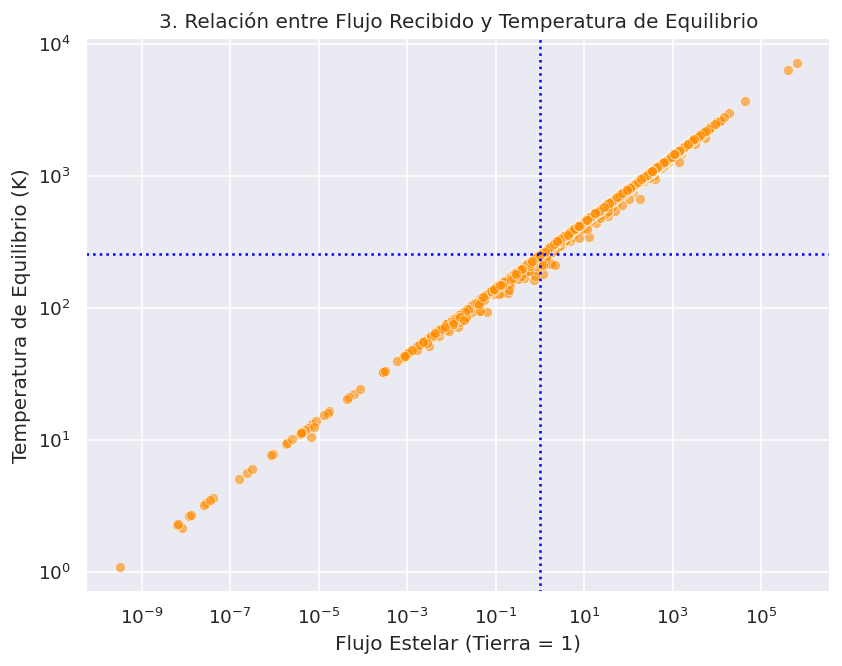

In [ ]:
fig4, ax4 = plt.subplots(figsize=(8, 6), dpi=120)

# Flujo Estelar vs Temperatura de Equilibrio
sns.scatterplot(data=df_clean, x='P_FLUX', y='P_TEMP_EQUIL', color='darkorange', alpha=0.6, ax=ax4)
ax4.set_title('3. Relación entre Flujo Recibido y Temperatura de Equilibrio')
ax4.set_xlabel('Flujo Estelar (Tierra = 1)')
ax4.set_ylabel('Temperatura de Equilibrio (K)')
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.axvline(x=1, color='blue', linestyle=':')
ax4.axhline(y=255, color='blue', linestyle=':')

plt.show()

/tmp/ipykernel_12343/1193679384.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_habitables,


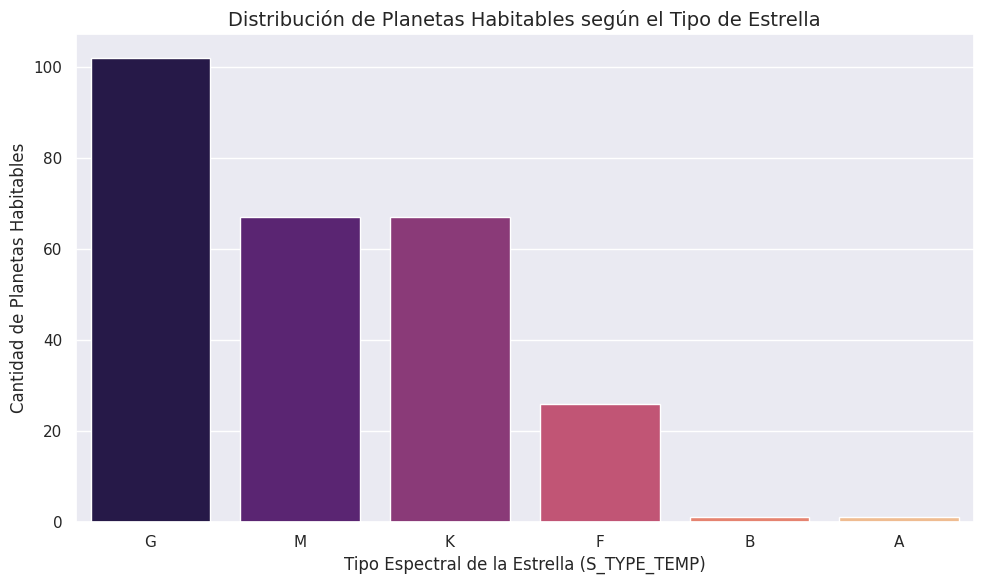

In [ ]:
plt.figure(figsize=(10, 6))

# Filtramos para quedarnos solo con los planetas en la zona habitable optimista
df_habitables = df[df['P_HABZONE_OPT'] == 1].copy()

# Eliminamos temporalmente los que no tengan el dato del tipo de estrella para no graficar nulos
df_habitables = df_habitables.dropna(subset=['S_TYPE_TEMP'])

# Creamos el gráfico de barras (countplot cuenta automáticamente las frecuencias)
# Usamos 'order' para que las barras aparezcan ordenadas de mayor a menor
sns.countplot(data=df_habitables,
              x='S_TYPE_TEMP',
              order=df_habitables['S_TYPE_TEMP'].value_counts().index,
              palette='magma')

plt.title('Distribución de Planetas Habitables según el Tipo de Estrella', fontsize=14)
plt.xlabel('Tipo Espectral de la Estrella (S_TYPE_TEMP)', fontsize=12)
plt.ylabel('Cantidad de Planetas Habitables', fontsize=12)

plt.tight_layout()
plt.show()

# EXPLICACIÓN GRÁFICO 3

Al analizar la relación entre el flujo estelar recibido y la temperatura de equilibrio, se encontró una tendencia positiva muy marcada, siendo los planetas que reciben mayor flujo los que tienen temperaturas significativamente más altas. Los puntos se distribuyen siguiendo una tendencia casi lineal en escala logarítmica, lo que sugiere una relación física bien definida entre ambas variables.

Esta tendencia concuerda con que la temperatura de equilibrio de un planeta depende directamente de la radiación incidente de su estrella, por lo que un aumento en el flujo implica un incremento sistemático de la temperatura. La dispersión de los datos es pequeña, lo que indica que el flujo estelar es el factor más importante para determinar el estado térmico de los planetas.

En el gráfico, las líneas punteadas marcan una zona de interés con valores de flujo y temperatura similares a los terrestres. Solo una baja fracción de los planetas está en esta zona, la mayoría está hacia valores de flujo mayor, y por lo tanto temperaturas más altas. Esto apunta a que la mayoría de planetas en el conjunto de datos están muy irradiados.

Al relacionar este resultado con la distribución de planetas con el tipo espectral estelar, se puede concluir que esta acumulación en los altos flujos está afectada por la naturaleza de las estrellas anfitrionas. Las estrellas más luminosas tienden a producir flujos más intensos, que desplazan a los planetas a temperaturas más elevadas, mientras que las estrellas más frías (K y M) permiten que los planetas existan en rangos de flujo más moderados. Pero incluso así, los planetas detectados tienden a estar en órbitas cercanas, lo que aumenta el flujo recibido y refuerza esta tendencia.

En conjunto, estos resultados indican que la temperatura de equilibrio está regulada por el flujo estelar, pero también revelan un importante sesgo observacional, los métodos de detección favorecen a los planetas cercanos a sus estrellas, que reciben más irradiación. Por eso, la baja densidad de puntos en la región de condiciones similares a las terrestres no refleja su escasez real, sino las limitaciones actuales en la detección de exoplanetas templados.


## Discusión de resultados
A partir de las gráficas exploradas, damos cuenta que hay una predominancia de planetas que se encuentran más cerca de sus respectivas estrellas y que por tanto reciben un mayor flujo, siguiendo la ley del inverso cuadrado. Esto introduce un aumento de la temperatura que imposibilitaría la presencia de agua líquida como primera posibilidad de habitabilidad.
Dado lo anterior es que el flujo estelar resulta un estimador crucial a la hora de identificar potenciales planetas habitables.  

Un resultado relevante a notar es que en la gráfica 2, notamos que la gran mayoría de los planetas en la zona conservadora se presentan flujos menores o iguales al de la Tierra. Recordemos que el índice Earth Similarity Index ESI es una magnitud adimensional que cuantifica cuán físicamente es el exoplaneta comparable con la Tierra, involucrando las propiedades de densidad, temperatura, entre otros. Notamos que mediante el índice, no podemos distinguir entre planetas rocosos o gaseosos.  

Si comparamos la temperatura de equilibrio y superficial de los planetas, notamos una cierta pendiente mayor a 1 de esta relación. Al comparar las distribuciones, notamos un leve desplazamiento de esta hacia temperaturas más grandes, que se ve justificado por la comparación de $T_{eq}$ vs $T_{sup}$.

Finalmente, destacamos la preponderancia de estrellas tipo G hospedantes de potenciales planetas habitables, seguido de estrellas tipo K y M. Hemos de mencionar que las estrellas más comunes en el Universo son las tipo M, y resulta llamativo que no representen la mayoría de la distribución, sino estrellas tipo Sol. Podemos inferir de esto que es necesario una cierta cantidad de energía radiada en un sistema tal que exista una zona habitable a una distancia apropiada donde se sitúe un planeta.

# Selección de candidatos

Para seleccionar los candidatos, consideraremos aquellos que estén dentro de la zona habitable de su estrella hospedante. Además, acotaremos la lista para aquellos que tengan su temperatura de equilibrio entre 250 y 300 K, considerando que la de la Tierra es cercana a 255 K.

In [ ]:
# Seleccionamos planetas que estén en la HZ Conservadora y minimizamos la diferencia de flujo con la Tierra
candidatos_termicos = df_clean[
    (df_clean['P_HABZONE_CON'] == 1) &
    (df_clean['P_TEMP_EQUIL'] >= 250) &
    (df_clean['P_TEMP_EQUIL'] <= 313)
].sort_values(by='FLUX_DIFF_EARTH', ascending=True) # Los que tienen flujo más cercano a 1 primero

top_3 = candidatos_termicos.head(3)
print("Los 3 candidatos más sólidos (Flujo más idéntico a la Tierra en la Zona Habitable):")
print(top_3[['P_NAME', 'P_FLUX', 'P_TEMP_EQUIL', 'P_ESI', 'P_SEMI_MAJOR_AXIS']])

Los 3 candidatos más sólidos (Flujo más idéntico a la Tierra en la Zona Habitable):
             P_NAME    P_FLUX  P_TEMP_EQUIL     P_ESI  P_SEMI_MAJOR_AXIS
5532  Kepler-1981 b  0.992703     254.27552  0.431129             1.3292
427     HD 191939 g  0.986469     253.83252  0.591222             0.8120
1609  Kepler-1554 b  1.014824     255.68039  0.655473             0.6314


A partir de nuestro análisis exploratorio, establecimos que el mejor indicador para predecir si un planeta tiene condiciones térmicas habitables es buscar aquellos que reciban un calor (flujo estelar) casi idéntico al de la Tierra. Bajo este criterio, nuestros tres candidatos más fuertes son:

In [ ]:
df_clean.loc[df_clean['P_NAME'] == 'Kepler-1981 b']

,P_NAME,P_FLUX,P_TEMP_EQUIL,P_TEMP_SURF,P_SEMI_MAJOR_AXIS,S_LUMINOSITY,S_TEMPERATURE,P_DISTANCE_EFF,P_HABZONE_OPT,P_HABZONE_CON,S_HZ_CON_MAX,P_ESI,P_HABITABLE,FLUX_DIFF_EARTH
5532,Kepler-1981 b,0.992703,254.27552,NaN,1.3292,1.75388,5874.0,1.3292,1,1,2.201699,0.431129,0,0.007297


In [ ]:
df_clean.loc[df_clean['P_NAME'] == 'HD 191939 g']

,P_NAME,P_FLUX,P_TEMP_EQUIL,P_TEMP_SURF,P_SEMI_MAJOR_AXIS,S_LUMINOSITY,S_TEMPERATURE,P_DISTANCE_EFF,P_HABZONE_OPT,P_HABZONE_CON,S_HZ_CON_MAX,P_ESI,P_HABITABLE,FLUX_DIFF_EARTH
427,HD 191939 g,0.986469,253.83252,NaN,0.812,0.65013,5348.0,0.812091,1,1,1.403819,0.591222,0,0.013531


In [ ]:
df_clean.loc[df_clean['P_NAME'] == 'Kepler-1554 b']

,P_NAME,P_FLUX,P_TEMP_EQUIL,P_TEMP_SURF,P_SEMI_MAJOR_AXIS,S_LUMINOSITY,S_TEMPERATURE,P_DISTANCE_EFF,P_HABZONE_OPT,P_HABZONE_CON,S_HZ_CON_MAX,P_ESI,P_HABITABLE,FLUX_DIFF_EARTH
1609,Kepler-1554 b,1.014824,255.68039,NaN,0.6314,0.404576,5297.0,0.6314,1,1,1.112446,0.655473,0,0.014824


* **Kepler-1981 b:** Recibe un flujo estelar de 0.9927 y tiene una temperatura de equilibrio de 254.2 K. Su ESI es bastante bajo (0.43), pero en criterios térmicos es un buen candidato
* **HD 191939 g:** Recibe un flujo estelar de 0.9864, su temperatura de equilibrio es de 253.8 K y presenta un ESI un poco mayor de 0.59
* **Kepler-1554 b:** Recibe un flujo estelar de 1.0148 y tiene una temperatura de equilibrio de 255.6 K, muy cercana a los ~255 K de nuestro planeta. Su ESI es de 0.65.
### Justificación de la selección:
Elegimos estos planetas porque la cantidad de energía que reciben de su estrella asegura que no sean ni extremadamente fríos ni extremadamente calientes. Al mantener un flujo cercano a 1, maximizamos las probabilidades de que el planeta tenga una temperatura adecuada para albergar agua líquida. Consideramos que Kepler-1554 b es el candidato más sólido del grupo, ya que además de cumplir con los requisitos térmicos ideales, es aquel que presenta el mayor valor de ESI.

# Conclusiones
Nuestro análisis confirma que la temperatura de un exoplaneta depende directamente del flujo de radiación que recibe de su estrella. Al revisar el catálogo, notamos que la mayoría de los planetas descubiertos son extremadamente calientes, esto significa que los planetas con altas temperaturas son mucho más fáciles de detectar con la tecnología actual.  
Aun con esta limitación, cuando filtramos los datos buscando condiciones de radiación similares a las de la Tierra, aparecieron candidatos de interés como Kepler-1981 b, HD 191939 g y Kepler-1554 b. Estos planetas destacan porque sus temperaturas de equilibrio son muy parecidas a la nuestra.  
Sin embargo, definir si un planeta es habitable no es algo que se pueda resolver con un solo dato. Aunque el filtro térmico es un gran punto de partida, por sí solo podría llevarnos a elegir planetas gaseosos que, aunque tengan la temperatura ideal, carecen de una superficie sólida.  
Por otro lado, debemos considerar que estos filtros están diseñados para buscar condiciones aptas para organismos similares a nosotros. Si bien en mundos con características muy distintas sería imposible encontrar vida tal como la conocemos, eso no descarta que puedan existir formas de vida basadas en otros principios bioquímicos o adaptadas a entornos extremos. Finalmente concluimos que, la temperatura es clave para que exista agua líquida, pero es un dato que debe considerarse junto con el tamaño y la composición para entender el verdadero potencial biológico de un planeta.
